In [1]:
import json
import os
import sqlite3
from datetime import date
from pathlib import Path
from typing import Any

import ipywidgets as widgets
import matplotlib.pyplot as plt
from dotenv import load_dotenv


In [2]:
def query_results(query: str, path2db: Path, parameters: tuple | None) -> list[Any]:
    if parameters is None:
        parameters = ()
    conn = sqlite3.connect(path2db)
    rows = conn.execute(query, parameters).fetchall()
    conn.close()
    return rows

In [3]:
# Get the path to the database file
if (str(Path.cwd()) == '/app'):
    data_dir = Path('/app/data.philiplessner.com')
else:
    load_dotenv()
    data_dir = Path(os.environ['DATA_FILE_DIR'])
path2db = Path(data_dir, 'logs.db')

In [4]:
# Get the starting and ending dates for the query
date_start = widgets.DatePicker(
    description='Start Date',
    value=date.today()  # noqa: DTZ011
)
date_end = widgets.DatePicker(
    description=' End Date',
    value=date.today()  # noqa: DTZ011
)
display(date_start)
display(date_end)

DatePicker(value=datetime.date(2026, 8, 25), description='Start Date', step=1)

DatePicker(value=datetime.date(2026, 8, 25), description=' End Date', step=1)

In [5]:
start_date = f"{date_start.value} 00:00:00"
end_date = f"{date_end.value} 23:59:59"
sdate = f"{date_start.value}"
edate = f"{date_end.value}"

In [6]:
country_query_humans = """
    SELECT countryCode, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND status_code <> 404
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY countryCode
    ORDER BY count DESC
    """

In [7]:
country_counts_humans = query_results(country_query_humans, path2db, (start_date, end_date))

In [8]:
countryCodes_humans = [countryCode for countryCode, _ in country_counts_humans]
counts_humans = [count for _, count in country_counts_humans]
total = sum(counts_humans)
percentages_humans = [count/total*100. for count in counts_humans]

In [9]:
country_query_robots = """
    SELECT countryCode, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'R'
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY countryCode
    ORDER BY count DESC
    """

In [10]:

country_counts_robots = query_results(country_query_robots, path2db, (start_date, end_date))

In [11]:

countryCodes_robots = [countryCode for countryCode, _ in country_counts_robots]
counts_robots = [count for _, count in country_counts_robots]
total = sum(counts_robots)
percentages_robots = [count/total*100. for count in counts_robots]

In [12]:
# Get n for top(n) countries to display
top_n = widgets.IntSlider(
    value=10,
    min=0,
    max=50,
    step=1,
    description='Value:',
    continuous_update=False
)

display(top_n)

IntSlider(value=10, continuous_update=False, description='Value:', max=50)

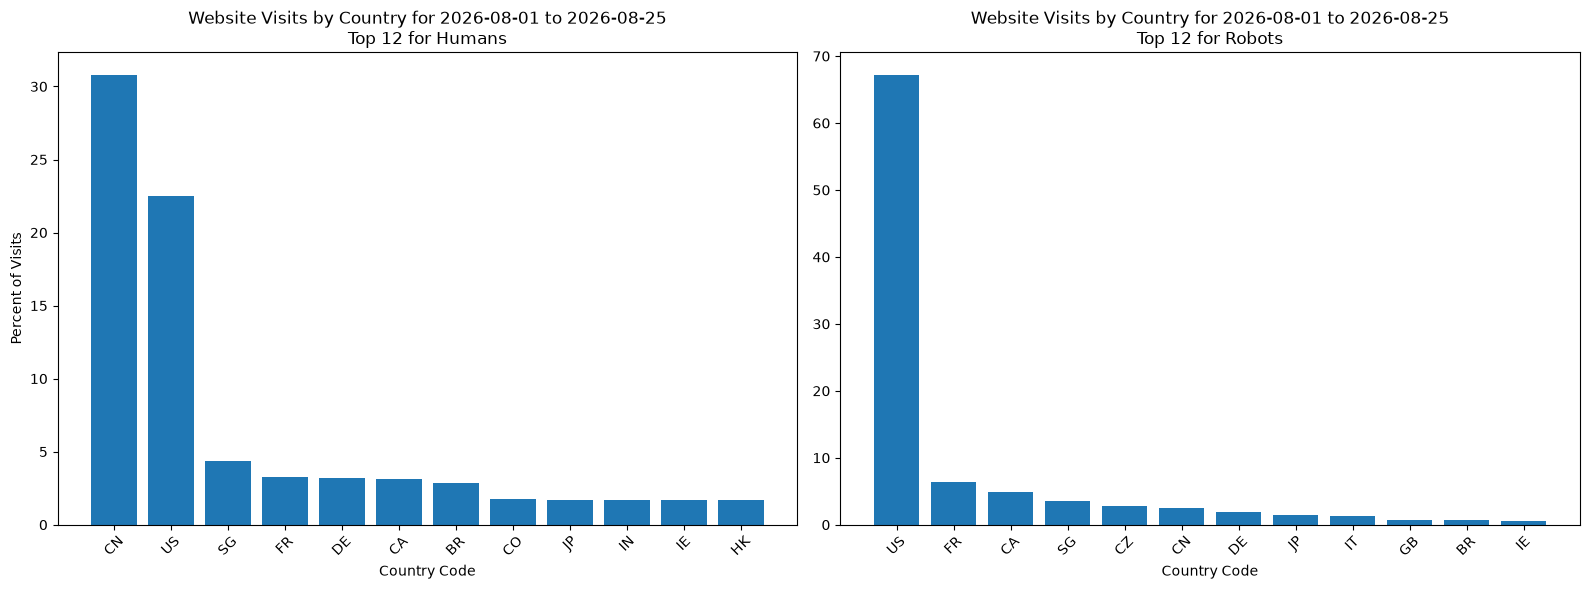

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(countryCodes_humans[:top_n.value], percentages_humans[:top_n.value])
axes[0].set_title(f'Website Visits by Country for {date_start.value} to {date_end.value}\nTop {top_n.value} for Humans')
axes[0].set_xlabel('Country Code')
axes[0].set_ylabel('Percent of Visits')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(countryCodes_robots[:top_n.value], percentages_robots[:top_n.value])
axes[1].set_title(f'Website Visits by Country for {date_start.value} to {date_end.value}\nTop {top_n.value} for Robots')
axes[1].set_xlabel('Country Code')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()


In [14]:
countryvisits_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(countryCodes_humans[:top_n.value])},
      datasets: [{{
        data: {json.dumps(percentages_humans[:top_n.value])},
        borderWidth: 1
      }}]
    }},
    options: {{
    plugins: {{
            title: {{
                display: true,
                text: 'Percent Website Visits by Country for {sdate} to {edate}',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                display: false,
                labels: {{
                    color: 'rgb(255, 99, 132)'
                }}
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Percent of (Human) Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Country Code',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'countryCode_percent.html'), 'w', encoding='utf-8') as f:
    f.write(countryvisits_html) 


In [15]:
endpoint_query_humans = """
    SELECT endpoint, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY endpoint
    ORDER BY count DESC
    """

In [16]:

endpoint_counts_humans = query_results(endpoint_query_humans, path2db, (start_date, end_date))

In [17]:
endpoints_humans = [endpoint for endpoint, _ in endpoint_counts_humans]
counts_humans = [count for _, count in endpoint_counts_humans]
total = sum(counts_humans)
percentages_humans = [count/total*100. for count in counts_humans]

In [19]:

endpoint_query_robots= """
    SELECT endpoint, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'R'
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY endpoint
    ORDER BY count DESC
    """

In [20]:

endpoint_counts_robots = query_results(endpoint_query_robots, path2db, (start_date, end_date))

In [22]:

endpoints_robots = [endpoint for endpoint, _ in endpoint_counts_robots]
counts_robots = [count for _, count in endpoint_counts_robots]
total = sum(counts_humans)
percentages_robots = [count/total*100. for count in counts_robots]

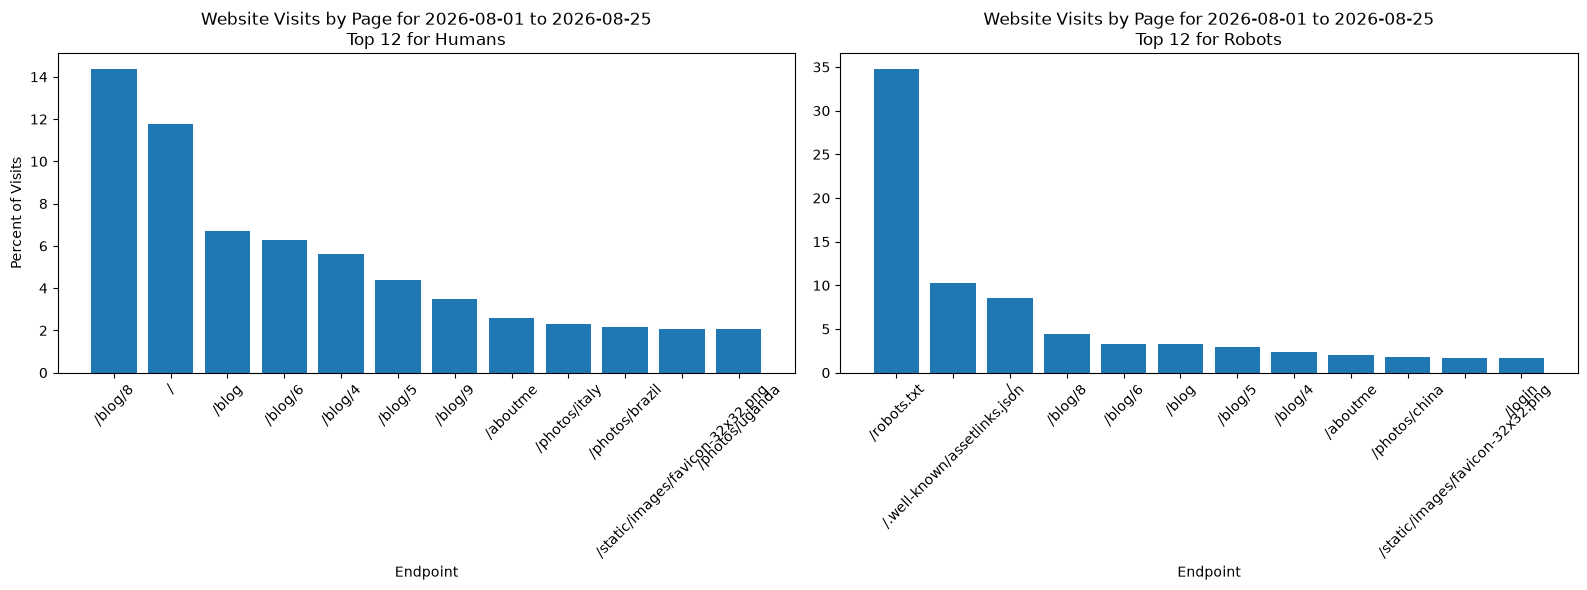

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(endpoints_humans[:top_n.value], percentages_humans[:top_n.value])
axes[0].set_title(f'Website Visits by Page for {date_start.value} to {date_end.value}\nTop {top_n.value} for Humans')
axes[0].set_xlabel('Endpoint')
axes[0].set_ylabel('Percent of Visits')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(endpoints_robots[:top_n.value], percentages_robots[:top_n.value])
axes[1].set_title(f'Website Visits by Page for {date_start.value} to {date_end.value}\nTop {top_n.value} for Robots')
axes[1].set_xlabel('Endpoint')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()

In [25]:

endpoint_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(endpoints_humans[:top_n.value])},
      datasets: [{{
        label: 'Percent Visits by Endpoint for {sdate} to {edate}',
        data: {json.dumps(percentages_humans[:top_n.value])},
        borderWidth: 1
      }}]
    }},
    options: {{
    plugins: {{
            title: {{
                display: true,
                text: 'Percent Visits by Endpoint for {sdate} to {edate}',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                display: false,
                labels: {{
                    color: 'rgb(255, 99, 132)'
                }}
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Percent of (Human) Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Endpoint',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'endpoint_percentages.html'), 'w', encoding='utf-8') as f:
    f.write(endpoint_html) 


In [26]:
visits_query = """
SELECT DATE(datetime) AS visit_day,
       COUNT(*) AS total_visits,
       COUNT(CASE WHEN Agent_Type = 'H' THEN 1 END) AS human_visits,
       COUNT(CASE WHEN Agent_Type = 'R' THEN 1 END) AS robot_visits
FROM logs
WHERE strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
AND status_code <> 404
GROUP BY DATE(datetime)
ORDER BY visit_day;
"""

In [27]:

visits_counts = query_results(visits_query, path2db, (start_date, end_date))

In [28]:
dates = [date for date, _, _, _ in visits_counts]
humans = [human for _,_, human, _ in visits_counts]
robots = [robot for _, _, _, robot in visits_counts]

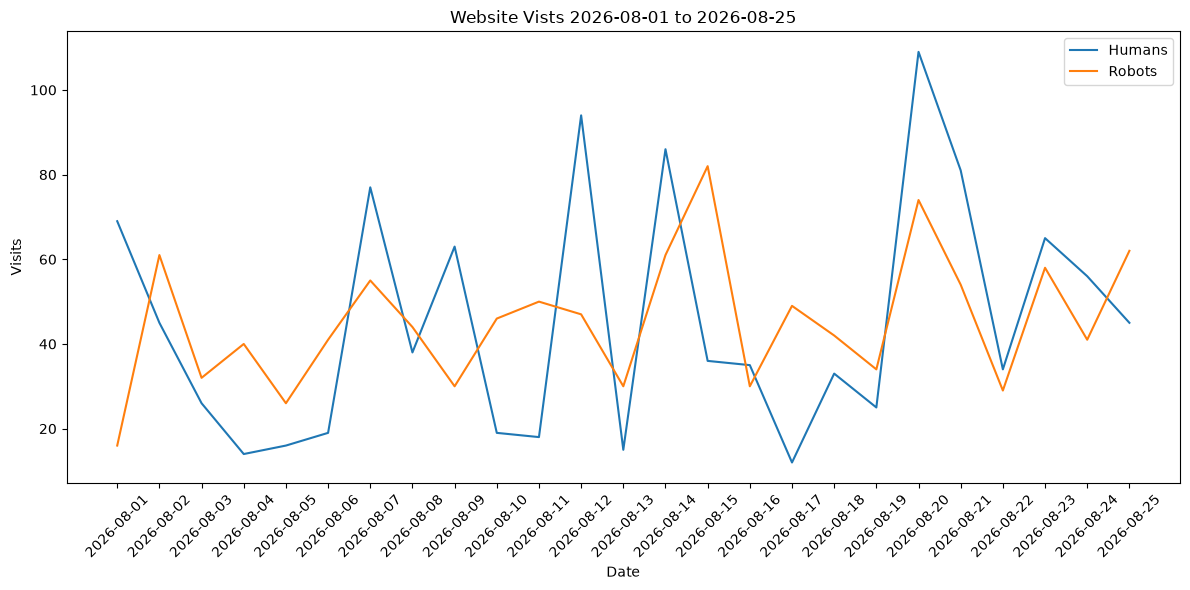

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(dates, humans, label='Humans')
plt.plot(dates, robots, label='Robots')
plt.title(f'Website Vists {sdate} to {edate}')
plt.xlabel('Date')
plt.ylabel('Visits')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

In [30]:
visitbytype_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="https://cdn.jsdelivr.net/npm/chart.js@4.5.1/dist/chart.umd.min.js"></script>

<script>
const ctx = document.getElementById('myChart').getContext('2d');

const myChart = new Chart(ctx, {{
    type: 'line', // Sets the chart type to line
    data: {{
        labels: {json.dumps(dates)}, // Shared X-axis labels
        datasets: [
            {{
                label: 'Humans', // Name shown in the legend
                data: {json.dumps(humans)},  // Y-axis values for the first line
                borderColor: 'rgb(255, 99, 132)', // Line color
                backgroundColor: 'rgba(255, 99, 132, 0.2)', // Fill color under the line
                tension: 0.1 // Makes the line slightly curved
            }},
            {{
                label: 'Robots', // Name shown in the legend
                data: {json.dumps(robots)},  // Y-axis values for the second line
                borderColor: 'rgb(54, 162, 235)', // Line color
                backgroundColor: 'rgba(54, 162, 235, 0.2)', // Fill color under the line
                tension: 0.1
            }}
        ]
    }},
    options: {{
        responsive: true, // Chart resizes automatically
        plugins: {{
            title: {{
                display: true,
                text: 'Daily Visits',
          font: {{
            family: 'Arial',
            size: 18,
          }}
            }},
            legend: {{
                position: 'right', // Legend placement
            }}
        }},
      scales: {{
        y: {{
          beginAtZero: true,
          title: {{
          display: true,
          text: 'Visits',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }},
        x: {{
          title: {{
          display: true,
          text: 'Date',
          color: '#111',
          font: {{
            family: 'Arial',
            size: 16,
          }}
          }}
        }}
      }}
    }}}})
</script>
</html>
"""
with open(Path(data_dir, 'visitbytype.html'), 'w', encoding='utf-8') as f:
    f.write(visitbytype_html) 